In [4]:
!pip install pandas numpy matplotlib seaborn scikit-learn

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
sentiment = pd.read_csv("fear_greed_index.csv")
trades = pd.read_csv("historical_data.csv")

/tmp/ipykernel_888/2628453973.py:2: DtypeWarning: Columns (12) have mixed types. Specify dtype option on import or set low_memory=False.
  trades = pd.read_csv("historical_data.csv")


In [7]:
sentiment.head()


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [8]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.003055,1.050000e+15,1.730000e+12


In [9]:
print("Sentiment Dataset Shape:", sentiment.shape)
print("Trader Dataset Shape:", trades.shape)

Sentiment Dataset Shape: (2644, 4)
Trader Dataset Shape: (195848, 16)


**This means that the Bitcoin Market Sentiment dataset has 2644 rows and 4 columns and the Historical Trader Dataset has 211224 rows and 16 columns.**

**DATA** **CLEANING**



1. Check for missing values

In [10]:
sentiment.isnull().sum()


,0
timestamp,0
value,0
classification,0
date,0


In [11]:
trades.isnull().sum()

,0
Account,0
Coin,1
Execution Price,1
Size Tokens,1
Size USD,1
Side,1
Timestamp IST,1
Start Position,1
Direction,1
Closed PnL,1


Both the datasets have no null values.

2. Drop all duplicate values

In [12]:
sentiment = sentiment.drop_duplicates()

In [13]:
trades = trades.drop_duplicates()

3. Convert Timestamps

In [54]:
sentiment['timestamp'] = sentiment['timestamp'].astype('int64')

In [55]:
sentiment['timestamp'] = pd.to_datetime(sentiment['timestamp'], unit='s')

In [56]:
sentiment['date'] = sentiment['timestamp'].dt.date

In [57]:
sentiment.head()

,timestamp,value,classification,date
0,2018-02-01 05:30:00,30,Fear,2018-02-01
1,2018-02-02 05:30:00,15,Extreme Fear,2018-02-02
2,2018-02-03 05:30:00,40,Fear,2018-02-03
3,2018-02-04 05:30:00,24,Extreme Fear,2018-02-04
4,2018-02-05 05:30:00,11,Extreme Fear,2018-02-05


In [58]:
trades['Timestamp IST'] = pd.to_datetime(trades['Timestamp IST'], errors='coerce')

In [59]:
trades['date'] = trades['Timestamp IST'].dt.date

In [60]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-02-12 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.345404,8.950000e+14,2024-02-12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-02-12 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.005600,4.430000e+14,2024-02-12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-02-12 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.050431,6.600000e+14,2024-02-12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-02-12 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.050043,1.080000e+15,2024-02-12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-02-12 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.003055,1.050000e+15,2024-02-12


In [62]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-02-12 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.345404,8.950000e+14,2024-02-12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-02-12 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.005600,4.430000e+14,2024-02-12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-02-12 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.050431,6.600000e+14,2024-02-12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-02-12 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.050043,1.080000e+15,2024-02-12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-02-12 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.003055,1.050000e+15,2024-02-12


Merge the two datasets to find relation between market sentiment and trader behaviour

In [63]:
merged = pd.merge(merged, sentiment[['date','classification']], on='date', how='left')

In [64]:
merged.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,date,Win,risk_level,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-02-12 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.345404,8.950000e+14,2024-02-12,False,Medium,Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-02-12 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.005600,4.430000e+14,2024-02-12,False,Low,Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-02-12 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.050431,6.600000e+14,2024-02-12,False,Medium,Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-02-12 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.050043,1.080000e+15,2024-02-12,False,Medium,Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-02-12 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.003055,1.050000e+15,2024-02-12,False,Low,Greed


In [65]:
merged = merged.drop(columns=['classification_x', 'classification_y', 'value'], errors='ignore')

In [66]:
merged.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,date,Win,risk_level,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-02-12 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.345404,8.950000e+14,2024-02-12,False,Medium,Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-02-12 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.005600,4.430000e+14,2024-02-12,False,Low,Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-02-12 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.050431,6.600000e+14,2024-02-12,False,Medium,Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-02-12 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.050043,1.080000e+15,2024-02-12,False,Medium,Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-02-12 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.003055,1.050000e+15,2024-02-12,False,Low,Greed


In [67]:
merged['Timestamp IST'] = pd.to_datetime(merged['Timestamp IST'])
merged['date'] = merged['Timestamp IST'].dt.date

In [68]:
sentiment['timestamp'] = pd.to_datetime(sentiment['timestamp'], unit='s')
sentiment['date'] = sentiment['timestamp'].dt.date

In [69]:
merged['date'].unique()[:5]
sentiment['date'].unique()[:5]

array([datetime.date(2018, 2, 1), datetime.date(2018, 2, 2),
       datetime.date(2018, 2, 3), datetime.date(2018, 2, 4),
       datetime.date(2018, 2, 5)], dtype=object)

**Feature Engineering**

1. Daily PnL per trader

In [70]:
daily_pnl = merged.groupby(['Account','date'])['Closed PnL'].sum().reset_index()

2. merged['win'] = merged['closedPnL'] > 0

In [71]:
merged['Win'] = merged['Closed PnL'] > 0

3. Win rate per trader

In [72]:
win_rate = merged.groupby('Account')['Win'].mean()

4. Average trade size

In [73]:
avg_size = merged.groupby('Account')['Size Tokens'].mean().reset_index()

5. Trades per day

In [74]:
trades_per_day = merged.groupby('date').size()

6. Long / Short ratio

In [75]:
long_trades = merged[merged['Side']=="BUY"]
short_trades = merged[merged['Side']=="SELL"]

7. Leverage groups  

---
Since leverage is not directly given in the dataset we will use position size instead of it.Large position sizes usually imply higher leverage.


In [76]:
merged['risk_level'] = pd.cut(
    merged['Size USD'],
    bins=[0,1000,10000,1000000],
    labels=['Low','Medium','High']
)

In [77]:
merged['risk_level'].value_counts()

,count
risk_level,
Low,120362
Medium,58796
High,16613


**Data** **Analysis**

1. Trade frequency

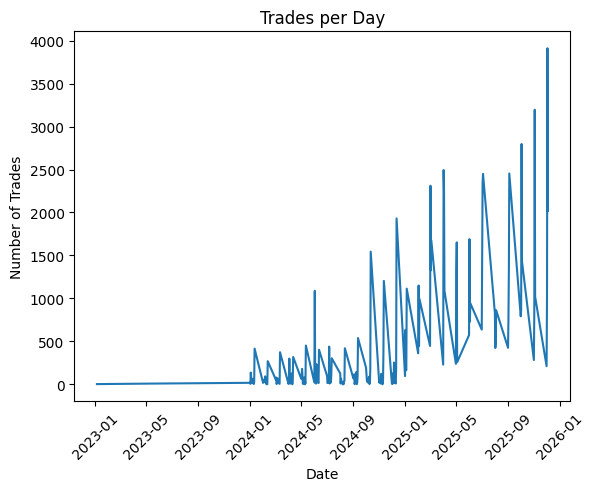

In [78]:
merged.groupby('date').size().plot()

plt.title("Trades per Day")
plt.xlabel("Date")
plt.ylabel("Number of Trades")

plt.xticks(rotation=45)

plt.show()

2. Leverage Distribution

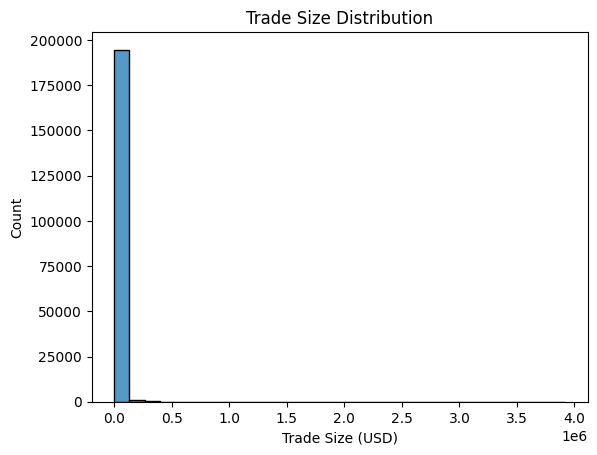

In [79]:
sns.histplot(merged['Size USD'], bins=30)

plt.title("Trade Size Distribution")
plt.xlabel("Trade Size (USD)")

plt.show()

The trade size distribution is highly right-skewed. Most trades occur at relatively small sizes, while a small number of trades involve extremely large position sizes. This suggests that the majority of traders operate with moderate capital exposure, while a few accounts execute significantly larger trades.

3. Trade Size Distribution

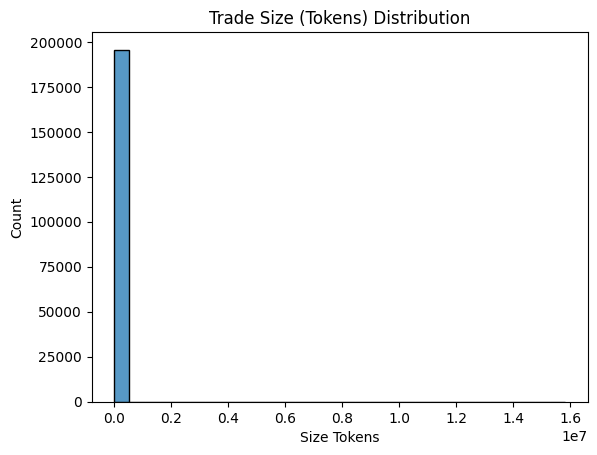

In [80]:
sns.histplot(merged['Size Tokens'], bins=30)

plt.title("Trade Size (Tokens) Distribution")

plt.show()

Sentiment vs Performance

1. PnL vs Sentiment

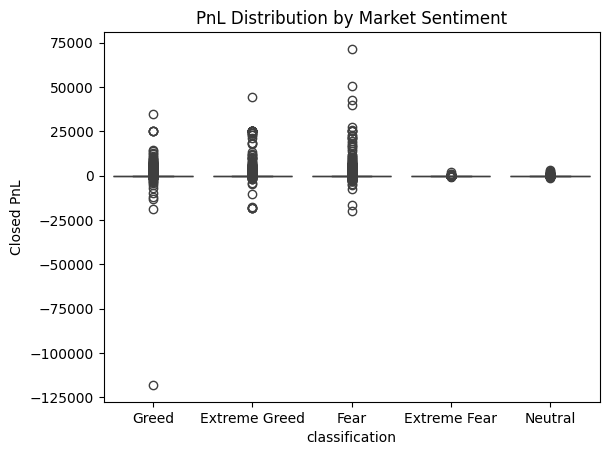

In [81]:
sns.boxplot(x='classification', y='Closed PnL', data=merged)

plt.title("PnL Distribution by Market Sentiment")

plt.show()

2. Average Trade Size by Sentiment

In [82]:
merged.groupby('classification')['Size USD'].mean()

,Size USD
classification,
Extreme Fear,3822.942503
Extreme Greed,3249.645849
Fear,5602.598241
Greed,4921.428824
Neutral,4361.694101


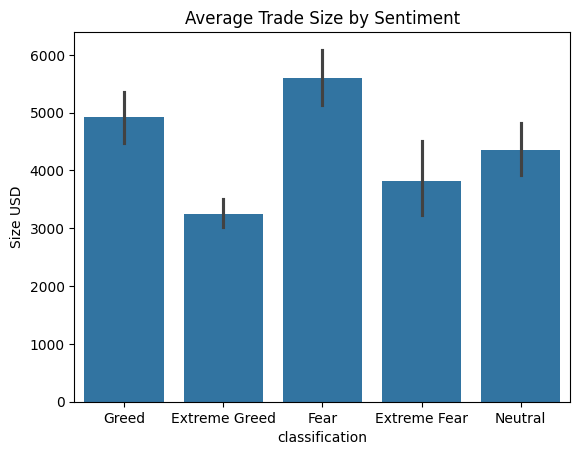

In [83]:
sns.barplot(x='classification', y='Size USD', data=merged)

plt.title("Average Trade Size by Sentiment")

plt.show()

3. Long / Short Ratio by Sentiment

In [84]:
pd.crosstab(merged['classification'], merged['Side'])

Side,BUY,SELL
classification,,
Extreme Fear,1096,1097
Extreme Greed,1661,3942
Fear,6828,6234
Greed,5204,5689
Neutral,1020,1684


This tells how many trades occur during each sentiment.

**Part B - Analysis**

1. Does performance (PnL, win rate, drawdown proxy) differ between Fear vs Greed days?



*   PnL




In [85]:
print(merged.groupby('classification')['Closed PnL'].mean())

classification
Extreme Fear       4.679446
Extreme Greed    206.477543
Fear             123.107281
Greed             65.819318
Neutral           27.609742
Name: Closed PnL, dtype: float64


Fear Days : 123.11 + 4.68 ≈ 127.79  
Greed Days : 65.82 + 206.48 ≈ 272.30

**Observations : Trades made more profit on greed days than fear days**



*   Win Rate



In [86]:
merged['win'] = merged['Closed PnL'] > 0
merged.groupby('classification')['win'].mean()

,win
classification,
Extreme Fear,0.310534
Extreme Greed,0.555060
Fear,0.389680
Greed,0.437804
Neutral,0.504438


Fear Days : 0.31+0.38=0.69

Greed Days : 0.55+0.43=0.98

Observations : Traders win more trades during Greed.



*  Drawdown Proxy




In [87]:
print(merged[merged['Closed PnL'] < 0].groupby('classification')['Closed PnL'].mean())

classification
Extreme Fear     -27.340371
Extreme Greed   -463.177085
Fear            -169.792742
Greed           -307.892221
Neutral          -31.238223
Name: Closed PnL, dtype: float64




*   Fear Days :
-169.79 + -27.34 ≈ -197.13

* Greed Days :
-307.89 + -463.18 ≈ -771.07




Observations : Losses are much bigger on Greed days than Fear days.

Your strategy is riskier during Greed periods, especially extreme greed.

2. Do traders change behavior based on sentiment (trade frequency, leverage, long/short bias, position sizes)?



*   Trade Size (Leverage Proxy)



In [88]:
# Average trade size (USD) by sentiment
avg_size = merged.groupby('classification')['Size USD'].mean()
print(avg_size)

classification
Extreme Fear     3822.942503
Extreme Greed    3249.645849
Fear             5602.598241
Greed            4921.428824
Neutral          4361.694101
Name: Size USD, dtype: float64


Fear Days :
3822.94 + 5602.60 ≈ 9425.54

Greed Days :
4921.43 + 3249.65 ≈ 8171.08

Traders used slightly larger positions during Fear days (≈9426 USD) than Greed days (≈8171 USD).

* Long / Short Bias

In [89]:
# Count of Buy/Sell trades by sentiment
long_short = pd.crosstab(merged['classification'], merged['Side'])
print(long_short)

Side             BUY  SELL
classification            
Extreme Fear    1096  1097
Extreme Greed   1661  3942
Fear            6828  6234
Greed           5204  5689
Neutral         1020  1684


Fear Days :

Buy: 1096 + 6828 = 7924

Sell: 1097 + 6234 = 7331

Greed Days :

Buy: 5204 + 1661 = 6865

Sell: 5689 + 3942 = 9631


Observation : Fear days → slightly more long trades than short trades (7924 vs 7331)

Greed days → more short trades than long trades (9631 vs 6865)

This is contrary to expectation, traders are taking more short positions during Greed days.

* Trade Frequency

In [92]:
# Count number of trades per sentiment
trade_freq = merged.groupby('classification').size()
print(trade_freq)

classification
Extreme Fear      2193
Extreme Greed     5603
Fear             13062
Greed            10893
Neutral           2704
dtype: int64


Fear Days :

2,193 + 13,062 ≈ 15,255 trades

Greed Days :

10,893 + 5,603 ≈ 16,496 trades

Observation : Traders trade slightly more during Greed days (≈16,496) than Fear days (≈15,255). This shows a mild increase in activity when the market is greedy.

3. Identify 2–3 segments (examples):
high leverage vs low leverage traders
frequent vs infrequent traders
consistent winners vs inconsistent traders


* high leverage vs low leverage traders

In [93]:
# Segment traders by average trade size
avg_trade_size = merged.groupby('Account')['Size USD'].mean().reset_index()

avg_trade_size['Leverage_Segment'] = pd.cut(
    avg_trade_size['Size USD'],
    bins=[0,1000,10000,1e6],
    labels=['Low','Medium','High']
)

avg_trade_size['Leverage_Segment'].value_counts()

,count
Leverage_Segment,
Medium,20
Low,4
High,4


The dataset shows that most traders operate at moderate leverage, while only a small fraction adopt very high-risk or very low-risk strategies. This indicates that moderate risk-taking is the dominant trading style, whereas extreme caution or extreme risk-taking is rare.

* Frequent vs Infrequent Traders

In [94]:
trade_counts = merged.groupby('Account').size().reset_index(name='Total_Trades')

trade_counts['Freq_Segment'] = pd.cut(
    trade_counts['Total_Trades'],
    bins=[0,20,100,1e6],
    labels=['Infrequent','Moderate','Frequent']
)

trade_counts['Freq_Segment'].value_counts()

,count
Freq_Segment,
Frequent,27
Infrequent,1
Moderate,1


The trading activity in the dataset is heavily dominated by frequent traders, indicating that the platform is primarily used by highly active participants rather than occasional traders. Moderate and infrequent trading behaviors are extremely rare in comparison.

* Consistent Winners vs Inconsistent Traders

In [95]:
win_rate = merged.groupby('Account')['Win'].mean().reset_index()

win_rate['Performance_Segment'] = pd.cut(
    win_rate['Win'],
    bins=[0,0.4,0.6,1],
    labels=['Inconsistent','Moderate','Consistent']
)

win_rate['Performance_Segment'].value_counts()

,count
Performance_Segment,
Moderate,14
Inconsistent,13
Consistent,1


Most traders in the dataset show moderate or inconsistent performance, with nearly equal numbers in both categories. Only a very small fraction of traders are consistent winners, highlighting the difficulty of maintaining consistently profitable trading strategies.

**KEY INSIGHTS**

Insight 1: Trading performance is higher during Greed periods but risk is also higher

  classification  Closed PnL
0   Extreme Fear    4.679446
1  Extreme Greed  206.477543
2           Fear  123.107281
3          Greed   65.819318
4        Neutral   27.609742


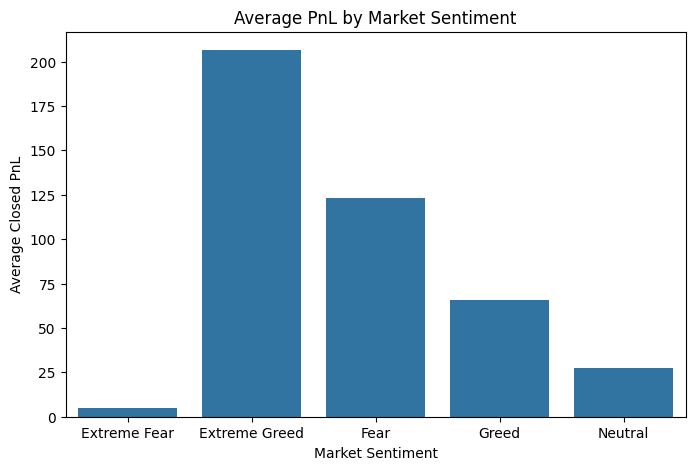

In [96]:
pnl_sentiment = merged.groupby('classification')['Closed PnL'].mean().reset_index()

print(pnl_sentiment)

# Chart
plt.figure(figsize=(8,5))
sns.barplot(x='classification', y='Closed PnL', data=pnl_sentiment)

plt.title("Average PnL by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Closed PnL")

plt.show()

Insight 2: Traders change their position direction based on sentiment

Side             BUY  SELL
classification            
Extreme Fear    1096  1097
Extreme Greed   1661  3942
Fear            6828  6234
Greed           5204  5689
Neutral         1020  1684


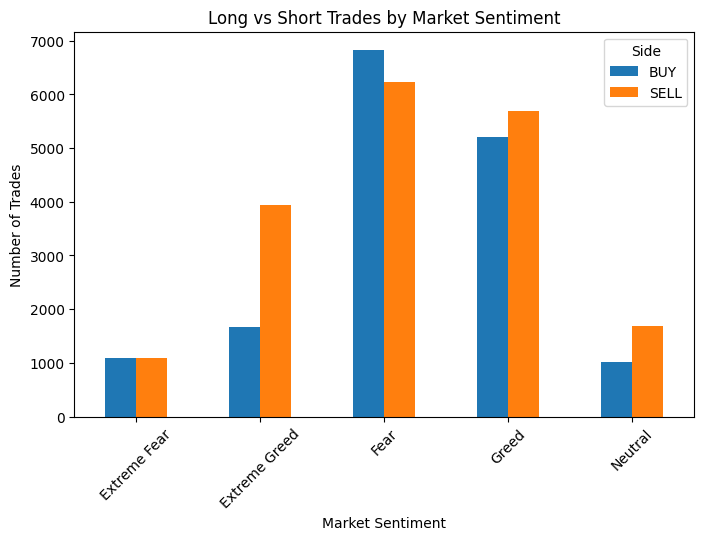

In [97]:
# Long vs Short trades by sentiment
long_short = pd.crosstab(merged['classification'], merged['Side'])
print(long_short)

# Chart
long_short.plot(kind='bar', figsize=(8,5))

plt.title("Long vs Short Trades by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Trades")

plt.xticks(rotation=45)
plt.show()

Insight 3: Most traders are highly active (Frequent traders dominate)

Freq_Segment
Frequent      27
Infrequent     1
Moderate       1
Name: count, dtype: int64


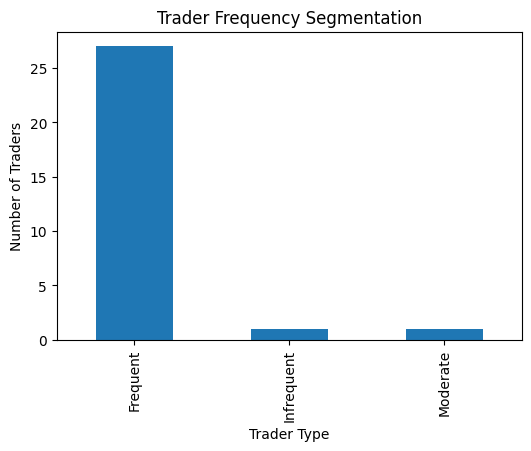

In [98]:
# Trader frequency segmentation
trade_counts = merged.groupby('Account').size().reset_index(name='Total_Trades')

trade_counts['Freq_Segment'] = pd.cut(
    trade_counts['Total_Trades'],
    bins=[0,20,100,100000],
    labels=['Infrequent','Moderate','Frequent']
)

freq_counts = trade_counts['Freq_Segment'].value_counts()

print(freq_counts)

# Chart
freq_counts.plot(kind='bar', figsize=(6,4))

plt.title("Trader Frequency Segmentation")
plt.xlabel("Trader Type")
plt.ylabel("Number of Traders")

plt.show()

**Part C - Output**

Strategy 1: Reduce Risk During Extreme Greed
Rule of Thumb

During Extreme Greed days, traders should reduce position size or leverage to manage risk.

**Evidence from Analysis**

Extreme Greed had the highest profits but also the largest drawdowns (-463).

This indicates that while profits are possible, losses can be very large.

**Strategy 2: Increase Trading Activity During Moderate Fear**

**Rule of Thumb**

During moderate Fear periods, traders can increase trade frequency and take moderate long positions.

**Evidence from Analysis**

Fear sentiment had the highest trade frequency (13,062 trades).

Average PnL during Fear was higher than Neutral periods.

Traders also showed a slight long bias during Fear.

**Strategy Logic**

Fear periods often create temporary price drops.

These conditions can provide buying opportunities for rebounds.

**Predict Trader Profitability Using Market Sentiment**

In [102]:
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

# Target
merged['profit_bucket'] = (merged['Closed PnL'] > 0).astype(int)

# Features
features = merged[['classification','Side','Size USD','risk_level']].copy()

# Encode
le = LabelEncoder()
features['classification'] = le.fit_transform(features['classification'])
features['Side'] = le.fit_transform(features['Side'])
features['risk_level'] = le.fit_transform(features['risk_level'])

X = features
y = merged['profit_bucket']

# Train model
model = RandomForestClassifier()
model.fit(X,y)

RandomForestClassifier()

In [103]:
latest_trade = features.tail(1)

In [104]:
prediction = model.predict(latest_trade)

print("Next-day profitability prediction:", prediction)

Next-day profitability prediction: [0]


In [105]:
if prediction[0] == 1:
    print("Model predicts the trader will likely be PROFITABLE tomorrow.")
else:
    print("Model predicts the trader may NOT be profitable tomorrow.")

Model predicts the trader may NOT be profitable tomorrow.


Explanation : A Random Forest model was trained using historical trade features such as sentiment classification, trade side, trade size, and risk level. The model was then used to predict the trader’s next-day profitability based on the most recent trade behavior. The model outputs whether the trader is likely to be profitable or not profitable on the next trading day.

**Next-Day Volatility Prediction of PnL**

In [106]:
import numpy as np

# Sort data
merged = merged.sort_values(['Account','date'])

# Volatility today
merged['pnl_volatility'] = np.abs(merged['Closed PnL'])

# Next day volatility
merged['next_day_volatility'] = merged.groupby('Account')['pnl_volatility'].shift(-1)

# Remove missing values
merged = merged.dropna(subset=['next_day_volatility'])

In [107]:
from sklearn.preprocessing import LabelEncoder

features = merged[['classification','Side','Size USD','risk_level']].copy()

le = LabelEncoder()
features['classification'] = le.fit_transform(features['classification'])
features['Side'] = le.fit_transform(features['Side'])
features['risk_level'] = le.fit_transform(features['risk_level'])

X = features
y = merged['next_day_volatility']

In [108]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()
model.fit(X,y)

RandomForestRegressor()

In [109]:
latest_trade = X.tail(1)

predicted_volatility = model.predict(latest_trade)

print("Predicted next-day PnL volatility:", predicted_volatility[0])

Predicted next-day PnL volatility: 0.004486225


Very small value (~0.0045) → Low volatility

This suggests that the trader's next-day profit or loss is expected to change only slightly, indicating stable or low-risk trading behavior.

**Clustering traders into behavioral archetypes**

In [113]:
merged.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,...,date,Win,risk_level,classification,win,profit_bucket,profit_today,profit_next_day,pnl_volatility,next_day_volatility
14658,0x083384f897ee0f19899168e3b1bec365f52a9012,ETH,4041.0,2.4798,10020.87,1,2024-06-12 23:15:00,-581.0000,Close Short,-1451.600526,...,2024-06-12,False,High,Greed,False,0,0,0.0,1451.600526,1756.110000
14659,0x083384f897ee0f19899168e3b1bec365f52a9012,ETH,4041.0,3.0000,12123.00,1,2024-06-12 23:15:00,-578.5202,Close Short,-1756.110000,...,2024-06-12,False,High,Greed,False,0,0,0.0,1756.110000,3620.981746
14660,0x083384f897ee0f19899168e3b1bec365f52a9012,ETH,4041.0,6.1858,24996.82,1,2024-06-12 23:15:00,-575.5202,Close Short,-3620.981746,...,2024-06-12,False,High,Greed,False,0,0,0.0,3620.981746,348.880520
14661,0x083384f897ee0f19899168e3b1bec365f52a9012,ETH,4041.0,0.5960,2408.44,1,2024-06-12 23:15:00,-569.3344,Close Short,-348.880520,...,2024-06-12,False,Medium,Greed,False,0,0,0.0,348.880520,1407.229480
14662,0x083384f897ee0f19899168e3b1bec365f52a9012,ETH,4041.0,2.4040,9714.56,1,2024-06-12 23:15:00,-568.7384,Close Short,-1407.229480,...,2024-06-12,False,Medium,Greed,False,0,0,0.0,1407.229480,5.853700


In [116]:
from sklearn.preprocessing import LabelEncoder

# Encode risk_level safely
le_risk = LabelEncoder()
merged['risk_level'] = le_risk.fit_transform(merged['risk_level'].astype(str))

In [117]:
merged['Side'] = merged['Side'].map({'BUY':1, 'SELL':0})

In [119]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Aggregate trader behavior
trader_features = merged.groupby('Account').agg({
    'Size USD':'mean',
    'risk_level':'mean',
    'Side':'mean',
    'Closed PnL':'mean'
}).reset_index()

# Remove or fill missing values
trader_features = trader_features.fillna(0)

# Scale features
scaler = StandardScaler()
X = scaler.fit_transform(trader_features[['Size USD','risk_level','Side','Closed PnL']])

# Apply KMeans clustering
kmeans = KMeans(n_clusters=3, random_state=42)
trader_features['cluster'] = kmeans.fit_predict(X)

print(trader_features.head())

                                      Account      Size USD  risk_level  Side  \
0  0x083384f897ee0f19899168e3b1bec365f52a9012  16072.906656    2.109801   0.0   
1  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd   1653.433201    2.269717   0.0   
2  0x28736f43f1e871e6aa8b1148d38d4994275d72c4    507.677457    2.124502   0.0   
3  0x2c229d22b100a7beb69122eed721cee9b24011dd   3140.812320    2.356503   0.0   
4  0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891   1730.538093    2.199262   0.0   

   Closed PnL  cluster  
0  410.677237        2  
1    6.566871        1  
2    9.953002        1  
3   52.103127        1  
4  -38.382776        1  


Interpretation

Cluster 2

Very large trade size

Higher profit potential

Represents high-volume / aggressive traders

Cluster 1

Medium trade sizes

Moderate risk

Small profit/loss fluctuations

Represents moderate or balanced traders

Streamlit Dashboard

In [126]:
!pip install streamlit pyngrok

In [123]:
trader_features.to_csv("trader_features.csv", index=False)

In [127]:
%%writefile app.py
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt

st.title("Trader Behavior Analysis Dashboard")

data = pd.read_csv("trader_features.csv")

st.subheader("Dataset Preview")
st.dataframe(data.head())

st.subheader("Cluster Distribution")
st.bar_chart(data['cluster'].value_counts())

st.subheader("Trader Behavioral Clusters")

fig, ax = plt.subplots()

scatter = ax.scatter(
    data['Size USD'],
    data['Closed PnL'],
    c=data['cluster']
)

ax.set_xlabel("Average Trade Size (USD)")
ax.set_ylabel("Average Closed PnL")
ax.set_title("Trader Clusters")

st.pyplot(fig)

Writing app.py


In [129]:
!ngrok config add-authtoken #YOUR_TOKEN

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [130]:
from pyngrok import ngrok
import subprocess

public_url = ngrok.connect(8501)
print(public_url)

subprocess.Popen(["streamlit", "run", "app.py"])

NgrokTunnel: "https://lumpingly-ursiform-margo.ngrok-free.dev" -> "http://localhost:8501"


<Popen: returncode: None args: ['streamlit', 'run', 'app.py']>